In [1]:
# ============================================================
# КЛІТИНКА 1: Імпорти
# ============================================================
import json
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import ast
import os

In [2]:
# ============================================================
# КЛІТИНКА 2: Завантаження JSON файлів
# ============================================================
DATA_DIR = "Dataset/"

with open(f"{DATA_DIR}release_conditions.json", "r", encoding="utf-8") as f:
    conditions = json.load(f)

with open(f"{DATA_DIR}release_evidences.json", "r", encoding="utf-8") as f:
    evidences = json.load(f)

print(f"✅ Діагнозів: {len(conditions)}")
print(f"✅ Симптомів/антецедентів: {len(evidences)}")

✅ Діагнозів: 49
✅ Симптомів/антецедентів: 223


In [3]:
# ============================================================
# КЛІТИНКА 3: Словник кодів → читабельні назви (з question_en)
# ============================================================
symptom_names = {}

for code, info in evidences.items():
    question = info.get("question_en", "")

    if question:
        label = (question
                 .replace("Do you have ", "")
                 .replace("Have you had ", "")
                 .replace("Are you ", "")
                 .replace("Did you ", "")
                 .replace("Is there ", "")
                 .replace("Do you ", "")
                 .replace("Have you ", "")
                 .rstrip("?")
                 .strip())
        if len(label) > 50:
            label = label[:47] + "..."
        symptom_names[code] = label
    else:
        symptom_names[code] = code  # fallback на код

print(f"✅ Словник побудовано: {len(symptom_names)} записів")
print("\nПриклади:")
for code, name in list(symptom_names.items())[:5]:
    print(f"  {code} → {name}")

✅ Словник побудовано: 223 записів

Приклади:
  E_91 → a fever (either felt or measured with a thermom...
  E_55 → feel pain somewhere
  E_53 → pain somewhere, related to your reason for cons...
  E_57 → Does the pain radiate to another location
  E_54 → Characterize your pain:


In [4]:
# ============================================================
# КЛІТИНКА 4: Побудова графа зі статичними зв'язками
# ============================================================
G = nx.Graph()

for condition_name, cond_data in conditions.items():
    G.add_node(condition_name,
               node_type="diagnosis",
               severity=cond_data.get("severity", 0))

    for symptom_code in cond_data.get("symptoms", {}).keys():
        label = symptom_names.get(symptom_code, symptom_code)
        G.add_node(label, node_type="symptom", code=symptom_code)
        G.add_edge(condition_name, label, weight=1.0, edge_type="symptom")

    for ant_code in cond_data.get("antecedents", {}).keys():
        label = symptom_names.get(ant_code, ant_code)
        G.add_node(label, node_type="antecedent", code=ant_code)
        G.add_edge(condition_name, label, weight=0.5, edge_type="antecedent")

print(f"✅ Граф побудовано")
print(f"   Вузлів: {G.number_of_nodes()}")
print(f"   Ребер:  {G.number_of_edges()}")

first_diag = list(conditions.keys())[0]
print(f"\nПриклад вузлів для '{first_diag}':")
for n in list(G.neighbors(first_diag))[:5]:
    print(f"  → {n}")

✅ Граф побудовано
   Вузлів: 272
   Ребер:  888

Приклад вузлів для 'Spontaneous pneumothorax':
  → feel pain somewhere
  → pain somewhere, related to your reason for cons...
  → Does the pain radiate to another location
  → Characterize your pain:
  → How fast did the pain appear


In [5]:
# ============================================================
# КЛІТИНКА 5: Завантаження тренувальних пацієнтів
# ============================================================
train_path = f"{DATA_DIR}release_train_patients"

# Файл може бути без розширення або .csv
if os.path.exists(train_path + ".csv"):
    df = pd.read_csv(train_path + ".csv")
else:
    df = pd.read_csv(train_path)

print(f"✅ Пацієнтів завантажено: {len(df):,}")
print(f"   Колонки: {list(df.columns)}")
print(f"\nПерший рядок:")
print(df.iloc[0])

✅ Пацієнтів завантажено: 1,025,602
   Колонки: ['AGE', 'DIFFERENTIAL_DIAGNOSIS', 'SEX', 'PATHOLOGY', 'EVIDENCES', 'INITIAL_EVIDENCE']

Перший рядок:
AGE                                                                      18
DIFFERENTIAL_DIAGNOSIS    [['Bronchitis', 0.19171203430383882], ['Pneumo...
SEX                                                                       M
PATHOLOGY                                                              URTI
EVIDENCES                 ['E_48', 'E_50', 'E_53', 'E_54_@_V_161', 'E_54...
INITIAL_EVIDENCE                                                       E_91
Name: 0, dtype: object


In [6]:
# ============================================================
# КЛІТИНКА 6: Розрахунок частотних ваг α_ij = P(symptom | diagnosis)
# ============================================================
co_occurrence = defaultdict(lambda: defaultdict(int))
diagnosis_count = defaultdict(int)

print("Розрахунок частот (може зайняти хвилину)...")

for _, row in df.iterrows():
    diagnosis = row["PATHOLOGY"]
    diagnosis_count[diagnosis] += 1

    try:
        evid_list = ast.literal_eval(row["EVIDENCES"])
    except:
        continue

    for ev_code in evid_list:
        base_code = ev_code.split("_@_")[0]
        ev_name = symptom_names.get(base_code, base_code)
        co_occurrence[diagnosis][ev_name] += 1

# Оновлюємо ваги ребер у графі
for diagnosis, symp_freq in co_occurrence.items():
    total = diagnosis_count[diagnosis]
    for symptom, count in symp_freq.items():
        alpha_ij = count / total
        if G.has_edge(diagnosis, symptom):
            G[diagnosis][symptom]["weight"] = alpha_ij
        elif G.has_node(diagnosis):
            G.add_edge(diagnosis, symptom,
                       weight=alpha_ij,
                       edge_type="frequency")

print("✅ Ваги α_ij розраховано!")

# Показуємо топ-5 симптомів для першого діагнозу
example = list(conditions.keys())[0]
top5 = sorted(G[example].items(),
              key=lambda x: x[1]["weight"],
              reverse=True)[:5]
print(f"\nТоп-5 симптомів для '{example}':")
for symp, data in top5:
    print(f"  α={data['weight']:.3f}  →  {symp}")

Розрахунок частот (може зайняти хвилину)...
✅ Ваги α_ij розраховано!

Топ-5 симптомів для 'Spontaneous pneumothorax':
  α=3.653  →  feel pain somewhere
  α=2.265  →  Characterize your pain:
  α=1.000  →  pain somewhere, related to your reason for cons...
  α=1.000  →  Does the pain radiate to another location
  α=1.000  →  How fast did the pain appear


In [7]:
# ============================================================
# КЛІТИНКА 7: Збереження артефактів для Кроку 2 (BioBERT)
# ============================================================
diagnoses = [n for n, d in G.nodes(data=True)
             if d.get("node_type") == "diagnosis"]
symptoms  = [n for n, d in G.nodes(data=True)
             if d.get("node_type") in ("symptom", "antecedent")]

# Матриця суміжності
adj_matrix = np.zeros((len(diagnoses), len(symptoms)))
for i, diag in enumerate(diagnoses):
    for j, symp in enumerate(symptoms):
        if G.has_edge(diag, symp):
            adj_matrix[i][j] = G[diag][symp]["weight"]

np.save("adjacency_matrix.npy", adj_matrix)

with open("graph_metadata.json", "w", encoding="utf-8") as f:
    json.dump({"diagnoses": diagnoses, "symptoms": symptoms},
              f, ensure_ascii=False, indent=2)

print(f"✅ adjacency_matrix.npy  →  shape: {adj_matrix.shape}")
print(f"   Рядки = діагнози ({len(diagnoses)})")
print(f"   Стовпці = симптоми ({len(symptoms)})")
print(f"✅ graph_metadata.json збережено")

✅ adjacency_matrix.npy  →  shape: (49, 223)
   Рядки = діагнози (49)
   Стовпці = симптоми (223)
✅ graph_metadata.json збережено


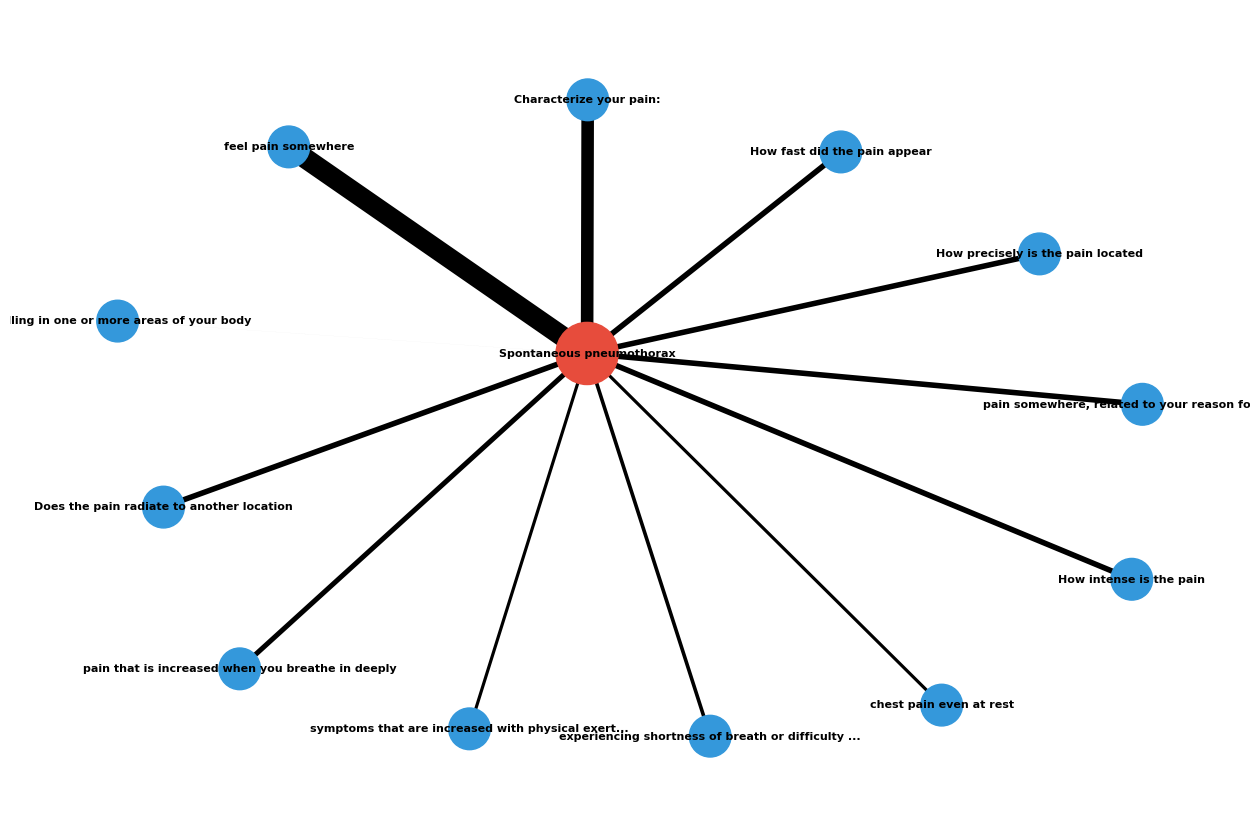


🎉 Крок 1 повністю завершено!
Наступний крок → завантаження BioBERT та векторизація вузлів графа


In [8]:
# ============================================================
# КЛІТИНКА 8: Візуалізація підграфу
# ============================================================
example_diagnosis = list(conditions.keys())[0]
neighbor_nodes = list(G.neighbors(example_diagnosis))[:12]
sub = G.subgraph([example_diagnosis] + neighbor_nodes)

fig, ax = plt.subplots(figsize=(16, 10))
pos = nx.spring_layout(sub, seed=42, k=3)

colors = ["#e74c3c" if G.nodes[n].get("node_type") == "diagnosis"
          else "#3498db" for n in sub.nodes()]
sizes  = [2000 if G.nodes[n].get("node_type") == "diagnosis"
          else 900 for n in sub.nodes()]
edge_weights = [sub[u][v]["weight"] * 4 for u, v in sub.edges()]

nx.draw(sub, pos, ax=ax,
        node_color=colors,
        node_size=sizes,
        width=edge_weights,
        with_labels=True,
        font_size=8,
        font_weight="bold")

ax.set_title(f"Граф знань: «{example_diagnosis}»", fontsize=14)
fig.savefig("graph_sample.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n🎉 Крок 1 повністю завершено!")
print("Наступний крок → завантаження BioBERT та векторизація вузлів графа")

In [9]:
# Додай в кінець першого файлу (після збереження matrix)
import pickle

with open("knowledge_graph.pkl", "wb") as f:
    pickle.dump(G, f)

print("✅ knowledge_graph.pkl збережено")

✅ knowledge_graph.pkl збережено
